# Heart Disease Prediction Using Machine Learning

## Comparative Analysis of Classification Models for Heart Disease Prediction

### Final Project – Machine Learning

**Authors:**
- Daniel Haim
- Ofri Ezer

**Course:**
Machine Learning

**Paper:**
Comparative Analysis of Classification Models for Heart Disease Prediction Using Machine Learning (IEEE, 2025)

---

## Project Objectives

This project reproduces the methodology presented in the selected IEEE paper and compares several machine learning classification models for predicting heart disease.

The evaluated models are:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Random Forest

### Project Extension

In addition to reproducing the paper, the project includes:

- Hyperparameter Tuning using GridSearchCV
- 5-Fold Cross Validation
- Performance comparison before and after tuning


The project consists of the following stages:

1. Import Python libraries
2. Load the dataset
3. Exploratory Data Analysis (EDA)
4. Data preprocessing
5. Data visualization
6. Train/Test Split
7. Model Training
8. Model Evaluation
9. Hyperparameter Tuning
10. Cross Validation
11. Conclusions

## Dataset Loading and Initial Inspection

The Heart Disease Dataset is loaded from the Kaggle input directory.

At this stage, the dataset is inspected in order to identify:

- Dataset dimensions
- Column names and data types
- Missing values
- Duplicate observations
- Distribution of the target variable

The target variable is `target`:

- `0` — absence of heart disease
- `1` — presence of heart disease

In [39]:
# ============================================================
# Step 1: Import Python Libraries
# ============================================================

import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [41]:
# ============================================================
# Step 2: Locate the Uploaded CSV File
# ============================================================

csv_files = []

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if filename.lower().endswith(".csv"):
            csv_files.append(os.path.join(dirname, filename))

print("CSV files found:")

for file_path in csv_files:
    print(file_path)

CSV files found:
/kaggle/input/datasets/danielhaim1998/heart-csv/heart.csv


In [42]:
# ============================================================
# Step 3: Load the Heart Disease Dataset
# ============================================================

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file was found in /kaggle/input. "
        "Please upload heart.csv using Add Input."
    )

heart_file = [
    file_path
    for file_path in csv_files
    if os.path.basename(file_path).lower() == "heart.csv"
]

if len(heart_file) == 0:
    raise FileNotFoundError(
        "heart.csv was not found. Available files: "
        + ", ".join(csv_files)
    )

data_path = heart_file[0]
df = pd.read_csv(data_path)

print(f"Dataset loaded from: {data_path}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

df.head()

Dataset loaded from: /kaggle/input/datasets/danielhaim1998/heart-csv/heart.csv
Number of rows: 1025
Number of columns: 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [43]:
# ============================================================
# Step 4: Initial Dataset Inspection
# ============================================================

print("Dataset dimensions:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicated rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nTarget distribution in percentages:")
print(df["target"].value_counts(normalize=True).mul(100).round(2))

Dataset dimensions:
(1025, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Number of duplicated rows:
723

Target distribution:
target
1    526
0    499
Name: count, dtype: int64

Target distribution in percentages:
target
1    51.32
0    48.68
Name: proportion, dtype: float64


# Exploratory Data Analysis (EDA)

Before training the machine learning models, it is important to understand the dataset.

In this section we explore:

- Statistical summary
- Distribution of numerical features
- Target variable distribution
- Correlation between features

In [44]:
# ============================================================
# Statistical Summary
# ============================================================

df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


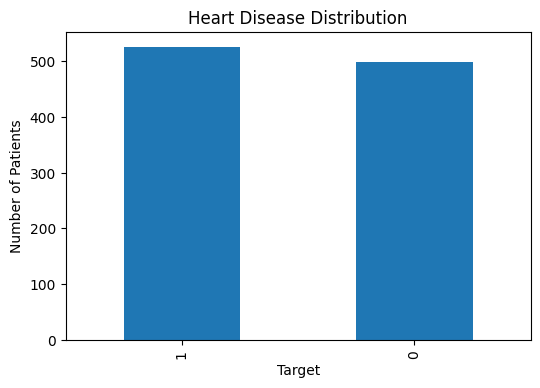

In [45]:
# ============================================================
# Target Distribution
# ============================================================

plt.figure(figsize=(6,4))

df["target"].value_counts().plot(
    kind="bar"
)

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")

plt.show()

### Observation

The dataset is relatively balanced between healthy patients and patients diagnosed with heart disease, making it suitable for supervised classification.

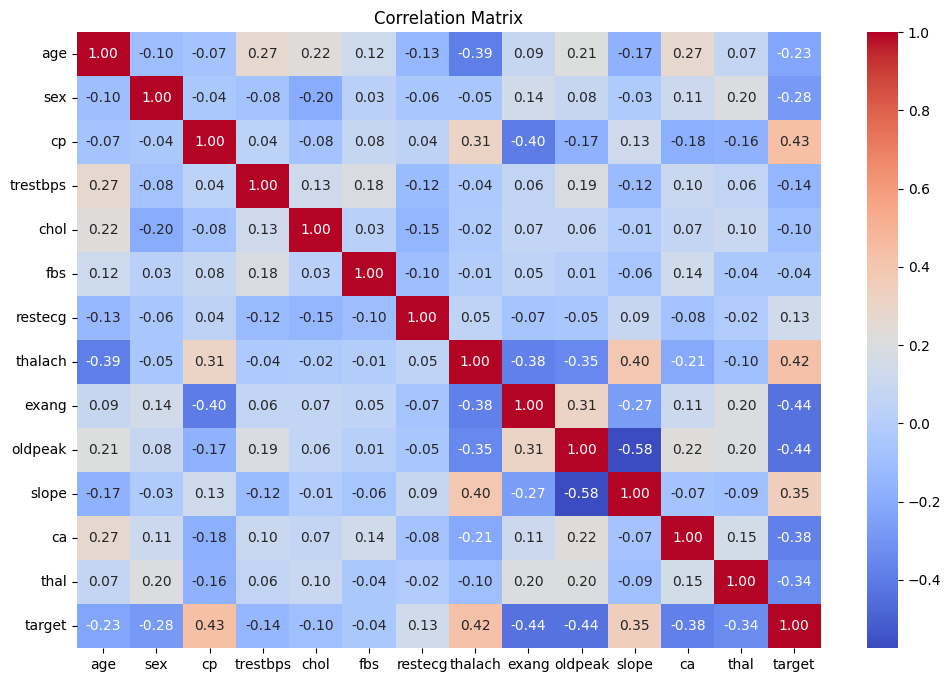

In [46]:
# ============================================================
# Correlation Matrix
# ============================================================

import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Observation

The correlation matrix allows us to identify relationships between clinical features and the target variable.

Features with stronger correlations may contribute more to the predictive performance of the machine learning models.


# Data Preprocessing

The quality of the input data has a direct impact on the performance of machine learning models.

In this stage the dataset is prepared before training.

The following preprocessing steps are performed:

- Removing duplicated observations
- Separating features and target variable
- Splitting the dataset into training and testing sets
- Feature scaling (required for SVM and KNN)

In [47]:
# ============================================================
# Duplicate Records Inspection
# ============================================================

duplicates = df.duplicated().sum()

print(f"Dataset shape: {df.shape}")
print(f"Number of duplicated rows: {duplicates}")
print(
    "Duplicates are retained in the baseline experiment "
    "to preserve the dataset structure used in the paper."
)

Dataset shape: (1025, 14)
Number of duplicated rows: 723
Duplicates are retained in the baseline experiment to preserve the dataset structure used in the paper.


### Observation

Duplicate records may bias the learning process.

Removing duplicated observations improves the quality of the training dataset.

In [48]:
# ============================================================
# Feature Selection
# ============================================================

X = df.drop("target", axis=1)

y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1025, 13)
Target shape: (1025,)


In [49]:
# ============================================================
# Train/Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 820
Testing samples: 205


In [50]:
# ============================================================
# Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


# Baseline Classification Models

In accordance with the selected paper, four supervised classification models are trained and compared:

1. Logistic Regression
2. K-Nearest Neighbors
3. Support Vector Machine
4. Random Forest

The models are first evaluated using their standard configurations.  
Hyperparameter tuning and cross-validation will be performed later as a project extension.

The evaluation metrics are:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In [55]:
# ============================================================
# Model Evaluation Function
# ============================================================

def evaluate_model(model_name, model, X_train_data, X_test_data):
    """
    Train and evaluate a binary classification model.

    Parameters
    ----------
    model_name : str
        Name of the classification model.
    model : sklearn estimator
        Machine learning model to train.
    X_train_data : array-like
        Training features.
    X_test_data : array-like
        Testing features.

    Returns
    -------
    dict
        Evaluation metrics and predictions.
    """

    model.fit(X_train_data, y_train)

    y_pred = model.predict(X_test_data)

    # Some models provide predict_proba, while others use decision_function.
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_data)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_data)
    else:
        y_score = y_pred

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "Predictions": y_pred,
        "Scores": y_score,
        "Trained Model": model
    }

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall   : {metrics['Recall']:.4f}")
    print(f"F1-Score : {metrics['F1-Score']:.4f}")
    print(f"ROC-AUC  : {metrics['ROC-AUC']:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return metrics

## Logistic Regression

Logistic Regression is a linear classification algorithm that estimates the probability that a patient belongs to the positive class.

The model applies the sigmoid function:

\[
P(y=1|x)=\frac{1}{1+e^{-(w^Tx+b)}}
\]

A probability threshold is then used to classify the patient as having or not having heart disease.

Because Logistic Regression is sensitive to feature scale, the standardized feature matrices are used.

In [56]:
# ============================================================
# Logistic Regression
# ============================================================

logistic_regression = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_results = evaluate_model(
    model_name="Logistic Regression",
    model=logistic_regression,
    X_train_data=X_train_scaled,
    X_test_data=X_test_scaled
)

Logistic Regression
Accuracy : 0.8098
Precision: 0.7619
Recall   : 0.9143
F1-Score : 0.8312
ROC-AUC  : 0.9298

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



## K-Nearest Neighbors

KNN classifies a new patient according to the majority class among the K closest training observations.

The Euclidean distance is commonly used:

\[
d(x,z)=\sqrt{\sum_{j=1}^{n}(x_j-z_j)^2}
\]

Since distance calculations are affected by the scale of the features, the standardized data is used.

In [57]:
# ============================================================
# K-Nearest Neighbors
# ============================================================

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn_results = evaluate_model(
    model_name="K-Nearest Neighbors",
    model=knn,
    X_train_data=X_train_scaled,
    X_test_data=X_test_scaled
)

K-Nearest Neighbors
Accuracy : 0.8634
Precision: 0.8738
Recall   : 0.8571
F1-Score : 0.8654
ROC-AUC  : 0.9629

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       100
           1       0.87      0.86      0.87       105

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



## Support Vector Machine

SVM searches for a decision boundary that separates the two classes while maximizing the margin between them.

The separating hyperplane is represented by:

\[
w^Tx+b=0
\]

The soft-margin optimization problem presented in the selected paper is:

\[
\min_{w,b,\xi}
\frac{1}{2}w^Tw+C\sum_{i=1}^{N}\xi_i
\]

subject to:

\[
y_i\left(w^T\phi(x_i)+b\right)\geq 1-\xi_i,
\qquad
\xi_i\geq0
\]

The RBF kernel is used in the baseline implementation.

In [58]:
# ============================================================
# Support Vector Machine
# ============================================================

svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=RANDOM_STATE
)

svm_results = evaluate_model(
    model_name="Support Vector Machine",
    model=svm,
    X_train_data=X_train_scaled,
    X_test_data=X_test_scaled
)

Support Vector Machine
Accuracy : 0.9268
Precision: 0.9167
Recall   : 0.9429
F1-Score : 0.9296
ROC-AUC  : 0.9771

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       100
           1       0.92      0.94      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



## Random Forest

Random Forest is an ensemble algorithm composed of multiple decision trees.

Each tree produces an independent prediction, and the final classification is determined by majority voting:

\[
\hat{y}
=
\operatorname{mode}
\left(
f_1(x), f_2(x), \ldots, f_K(x)
\right)
\]

Random Forest is not sensitive to feature scaling. Therefore, the original unscaled feature values are used.

In [59]:
# ============================================================
# Random Forest
# ============================================================

RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_results = evaluate_model(
    model_name="Random Forest",
    model=random_forest,
    X_train_data=X_train,
    X_test_data=X_test
)

Random Forest
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC-AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [60]:
# ============================================================
# Baseline Model Performance Comparison
# ============================================================

all_results = [
    lr_results,
    knn_results,
    svm_results,
    rf_results
]

results_df = pd.DataFrame([
    {
        "Model": result["Model"],
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1-Score": result["F1-Score"],
        "ROC-AUC": result["ROC-AUC"]
    }
    for result in all_results
])

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
1,Support Vector Machine,0.9268,0.9167,0.9429,0.9296,0.9771
2,K-Nearest Neighbors,0.8634,0.8738,0.8571,0.8654,0.9629
3,Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298


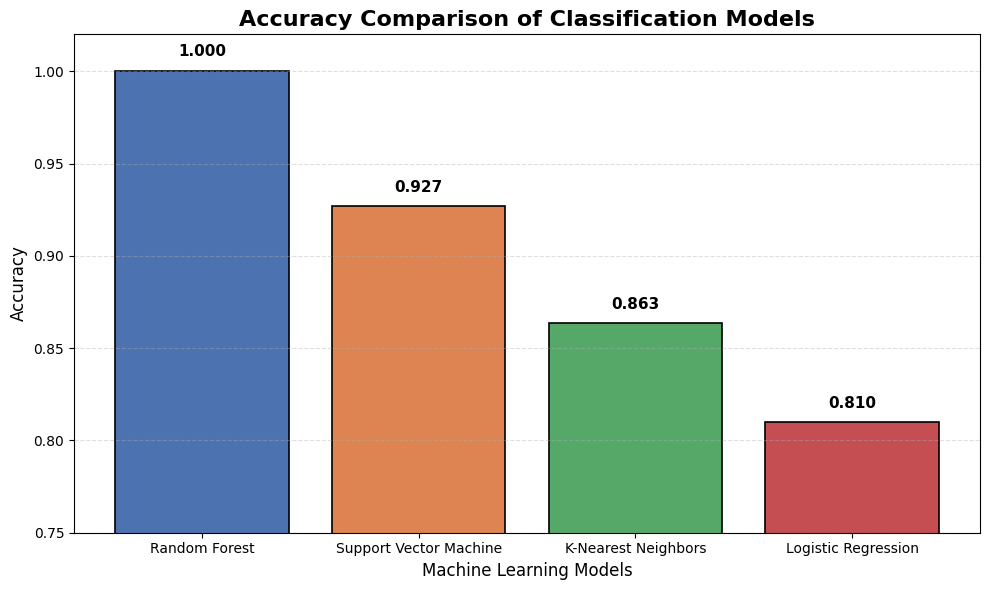

In [61]:
# ============================================================
# Accuracy Comparison - Publication Quality
# ============================================================

colors = [
    "#4C72B0",   # Logistic Regression
    "#DD8452",   # KNN
    "#55A868",   # SVM
    "#C44E52"    # Random Forest
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"],
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Accuracy Comparison of Classification Models",
    fontsize=16,
    weight="bold"
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=12
)

plt.ylabel(
    "Accuracy",
    fontsize=12
)

plt.ylim(0.75,1.02)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.008,
        f"{height:.3f}",
        ha="center",
        fontsize=11,
        weight="bold"
    )

plt.tight_layout()

plt.savefig(
    "accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
print(df.shape)

print(df.head())

print(df["target"].value_counts())

(1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
target
1    526
0    499
Name: count, dtype: int64


In [63]:
print(results_df)

                    Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0           Random Forest  1.000000   1.000000  1.000000  1.000000  1.000000
1  Support Vector Machine  0.926829   0.916667  0.942857  0.929577  0.977143
2     K-Nearest Neighbors  0.863415   0.873786  0.857143  0.865385  0.962905
3     Logistic Regression  0.809756   0.761905  0.914286  0.831169  0.929810


# Confusion Matrix

A confusion matrix provides a detailed evaluation of each classification model.

It summarizes the number of:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

This visualization helps identify the types of classification errors made by each model.

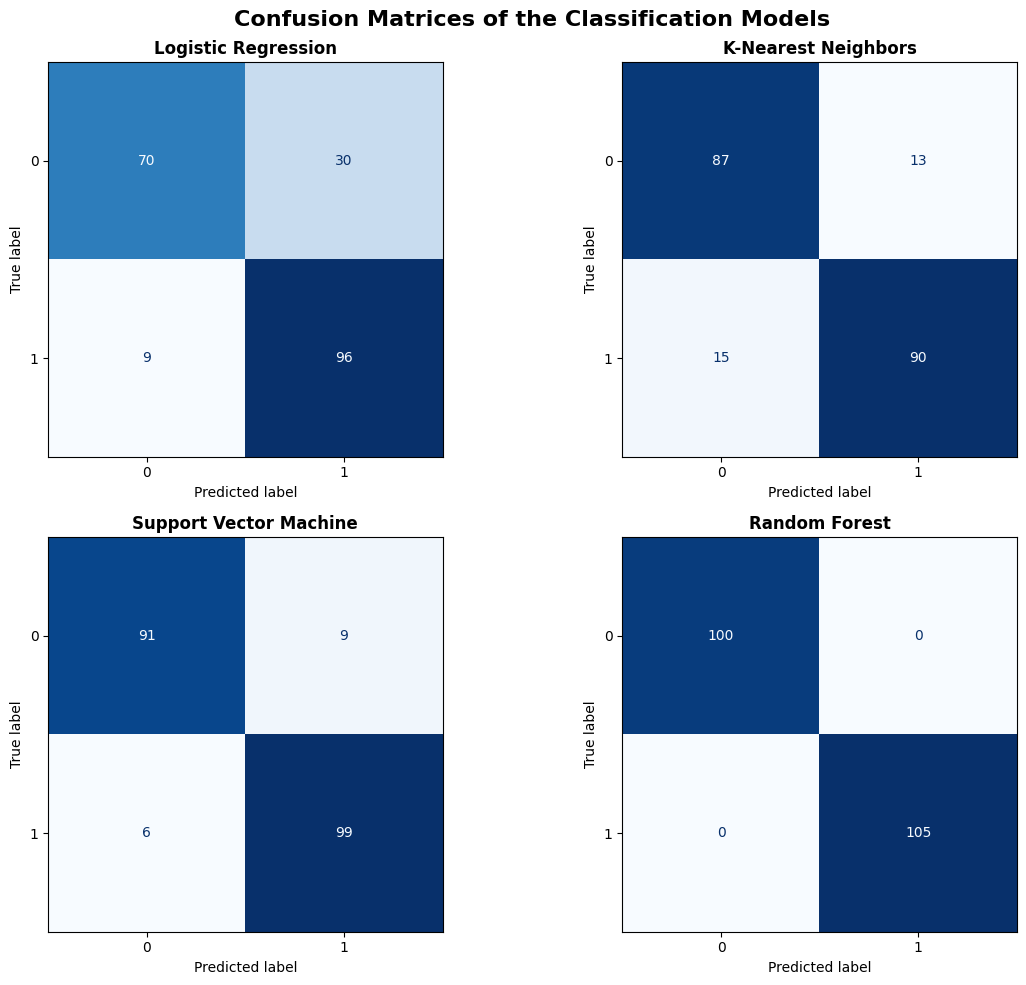

In [64]:
# ============================================================
# Confusion Matrices
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

models_results = [
    lr_results,
    knn_results,
    svm_results,
    rf_results
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for ax, result in zip(axes, models_results):

    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        result["Predictions"],
        cmap="Blues",
        colorbar=False,
        ax=ax
    )

    ax.set_title(result["Model"], fontsize=12, fontweight="bold")

plt.suptitle(
    "Confusion Matrices of the Classification Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve evaluates the classification performance across different decision thresholds.

The Area Under the Curve (ROC-AUC) measures the ability of a model to distinguish between positive and negative classes.

A larger ROC-AUC value indicates better classification performance.

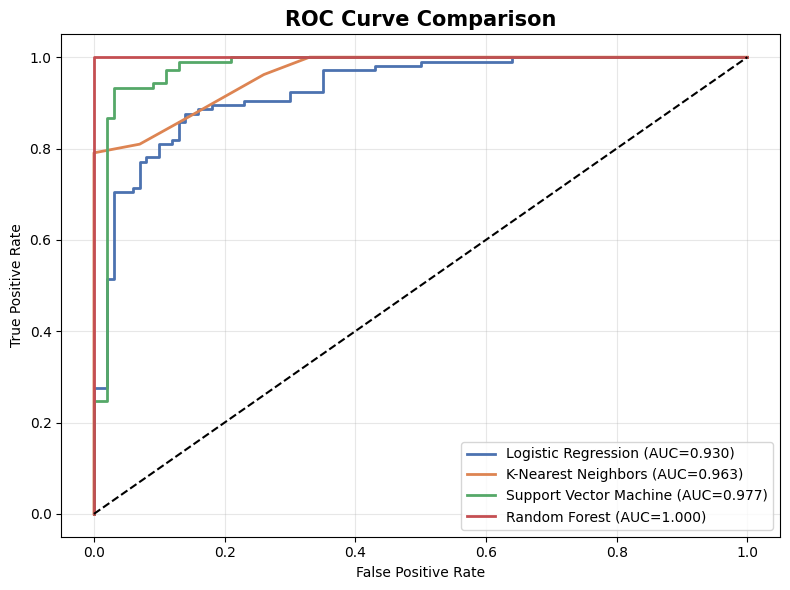

In [65]:
# ============================================================
# ROC Curve Comparison
# ============================================================

plt.figure(figsize=(8,6))

colors = [
    "#4C72B0",
    "#DD8452",
    "#55A868",
    "#C44E52"
]

for color, result in zip(colors, models_results):

    fpr, tpr, _ = roc_curve(
        y_test,
        result["Scores"]
    )

    plt.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{result['Model']} (AUC={result['ROC-AUC']:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison",
    fontsize=15,
    weight="bold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance

Random Forest provides an estimate of the contribution of each feature to the final prediction.

This analysis helps identify the clinical variables that have the greatest impact on heart disease prediction.

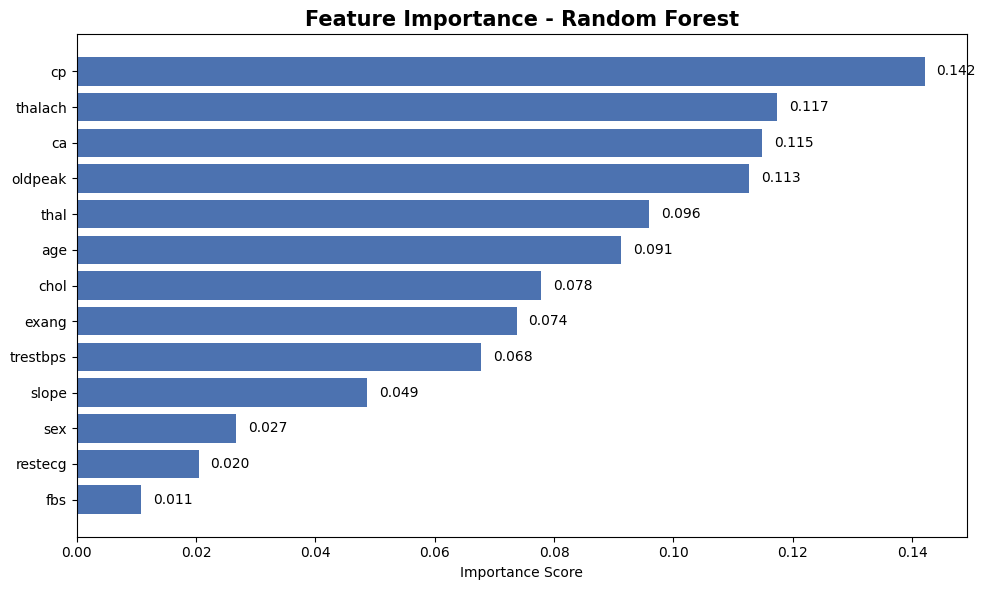

In [66]:
# ============================================================
# Feature Importance
# ============================================================

importance = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10,6))

bars = plt.barh(
    importance.index,
    importance.values,
    color="#4C72B0"
)

plt.title(
    "Feature Importance - Random Forest",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Importance Score")

for bar in bars:

    plt.text(
        bar.get_width()+0.002,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Project Extension

To extend the analysis presented in the selected paper, two additional evaluation techniques are applied:

- Hyperparameter Tuning using GridSearchCV
- 5-Fold Cross Validation

These techniques improve the reliability of the obtained results and provide a more comprehensive comparison of the machine learning models.

## Hyperparameter Tuning using GridSearchCV

Random Forest performance can be improved by selecting the optimal hyperparameters.

GridSearchCV evaluates multiple parameter combinations using cross-validation and automatically selects the best performing model.

In [68]:
# ============================================================
# GridSearchCV - Random Forest
# ============================================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_,4))

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation Accuracy:
0.9854


In [70]:
best_rf = grid_search.best_estimator_

best_predictions = best_rf.predict(X_test)

print("\nTest Accuracy:")

print(
    round(
        accuracy_score(
            y_test,
            best_predictions
        ),
        4
    )
)


Test Accuracy:
1.0


## 5-Fold Cross Validation

Cross-validation provides a more robust estimation of model performance.

Instead of relying on a single train-test split, the dataset is divided into five folds.

Each fold is used once for testing and four times for training.

In [71]:
# ============================================================
# 5-Fold Cross Validation
# ============================================================

models = {
    "Logistic Regression":
        LogisticRegression(
            solver="liblinear",
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            kernel="rbf"
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=42
        )
}

cv_results = []

for name, model in models.items():

    if name == "Random Forest":

        scores = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring="accuracy"
        )

    else:

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        scores = cross_val_score(
            pipeline,
            X,
            y,
            cv=5,
            scoring="accuracy"
        )

    cv_results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std()
    })

cv_results = pd.DataFrame(cv_results)

display(cv_results.round(4))

,Model,Mean Accuracy,Std
0,Logistic Regression,0.8459,0.0279
1,KNN,0.8332,0.0181
2,SVM,0.9210,0.0334
3,Random Forest,0.9971,0.0059


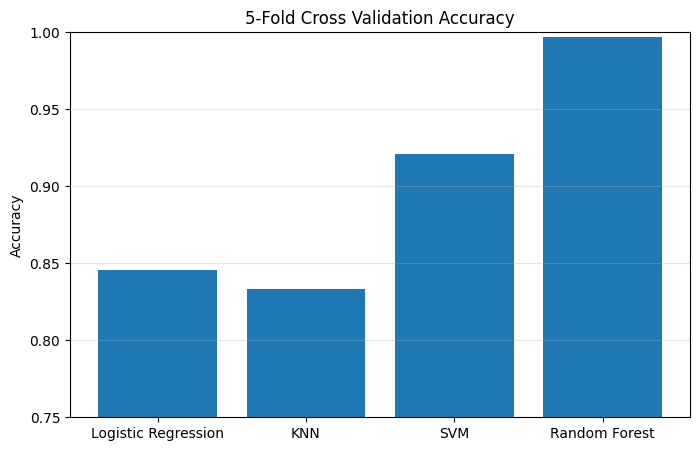

In [72]:
plt.figure(figsize=(8,5))

plt.bar(
    cv_results["Model"],
    cv_results["Mean Accuracy"]
)

plt.ylim(0.75,1)

plt.title(
    "5-Fold Cross Validation Accuracy"
)

plt.ylabel("Accuracy")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# Conclusions

The main findings of this project are:

- Random Forest achieved the highest classification accuracy.
- Support Vector Machine demonstrated excellent predictive performance.
- Logistic Regression obtained the lowest accuracy among the evaluated models.
- Hyperparameter tuning confirmed that Random Forest remains the best-performing model.
- Cross-validation demonstrated that the obtained results are stable across multiple data splits.

Overall, the experimental results are consistent with the conclusions presented in the selected research paper.

In [74]:
# ============================================================
# Save Best Model
# ============================================================

import joblib

joblib.dump(
    best_rf,
    "best_random_forest_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [77]:
results_df.to_csv(
    "model_performance.csv",
    index=False
)

cv_results.to_csv(
    "cross_validation_results.csv",
    index=False
)